In [1]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("D:/Data Eningeering/DE_Proj1_RealEstate/data/raw_data/mum_property_data_12182025.csv", usecols = ["Developer", "Project Name", "Units Available", "Price", "Carpet Area", "City", "Property", "Parking", "Maintenance Charges"])
data['Property'].unique()
data['Property'] = data.Property.str.replace('Flat', '').str.strip()
# data.loc[data['Property'] == '6 BHK']
data

,Developer,Units Available,Price,Maintenance Charges,Project Name,Carpet Area,Parking,City,Property
0,NaN,1.0,3150000.0,3.0,NaN,375.0,1 Covered,Thane,1 BHK
1,TATA Housing Development Company Ltd.,10.0,6300000.0,3.0,Tata Amantra,579.0,1 Covered,Thane,2 BHK
2,Sai Satyam Developers,0.0,5400000.0,1200.0,Sai Satyam Homes,585.0,1 Open,Thane,2 BHK
3,Birla Estates,70.0,9000000.0,3200.0,Birla Vanya,815.0,"1 Covered, 1 Open",Thane,2 BHK
4,Godrej Properties,NaN,4950000.0,NaN,Godrej Nirvaan,419.0,NaN,Thane,1 BHK
...,...,...,...,...,...,...,...,...,...
12680,Kalpataru Ltd.,NaN,22200000.0,NaN,Kalpataru Vivant,618.0,1 Covered,Mumbai,2 BHK
12681,Kalpataru Ltd.,20.0,31000000.0,12.0,Kalpataru Vivant,1076.0,1 Covered,Mumbai,3 BHK
12682,Kalpataru Ltd.,7.0,18500000.0,9.0,Kalpataru Vivant,618.0,1 Covered,Mumbai,2 BHK
12683,NaN,0.0,22000000.0,4000.0,NaN,821.0,1 Open,Mumbai,2 BHK


In [2]:
# data.Property.replace(to_replace=['1 BHK Flat', '2 BHK Flat', '3 BHK Flat', '4 BHK Flat', '5 BHK Flat', '6 BHK Flat'], value=['1 BHK', '2 BHK', '3 BHK', '4 BHK', '5 BHK', '6 BHK'])

# data.Property.str.replace('Flat', '').str.strip()
# data.Property
# data['Property'].unique()
mum_cities = ["Mumbai", "Thane", "Kalyan", "Palghar", "Bhiwandi"]
filtered_data = data[data.City.isin(mum_cities)].copy()

filtered_data['Parking'].unique()

filtered_data['Parking'] = filtered_data['Parking'].notnull().map({True: 'Yes', False: 'No'})

filtered_data['Parking'].unique()

#price cannot be negative or 0
filtered_data = filtered_data[filtered_data.Price > 0]

filtered_data['Price'].unique()

#carpet area should be between 20 and 10000
filtered_data = filtered_data[((filtered_data['Carpet Area']) > 100)  & (filtered_data['Carpet Area'] < 10000)]
filtered_data['Carpet Area'].unique()

#1BHK to 6 BHK max
filtered_data['BHK'] = filtered_data['Property'].str.extract(r"(\d+)")
filtered_data['BHK'] = pd.to_numeric(filtered_data['BHK'], errors="coerce")

filtered_data = filtered_data[filtered_data['BHK'].notnull()]

filtered_data['BHK'] = pd.to_numeric(filtered_data['BHK'], downcast="integer")
filtered_data = filtered_data[filtered_data['BHK'] <= 6]
filtered_data



,Developer,Units Available,Price,Maintenance Charges,Project Name,Carpet Area,Parking,City,Property,BHK
0,NaN,1.0,3150000.0,3.0,NaN,375.0,Yes,Thane,1 BHK,1
1,TATA Housing Development Company Ltd.,10.0,6300000.0,3.0,Tata Amantra,579.0,Yes,Thane,2 BHK,2
2,Sai Satyam Developers,0.0,5400000.0,1200.0,Sai Satyam Homes,585.0,Yes,Thane,2 BHK,2
3,Birla Estates,70.0,9000000.0,3200.0,Birla Vanya,815.0,Yes,Thane,2 BHK,2
4,Godrej Properties,NaN,4950000.0,NaN,Godrej Nirvaan,419.0,No,Thane,1 BHK,1
...,...,...,...,...,...,...,...,...,...,...
12680,Kalpataru Ltd.,NaN,22200000.0,NaN,Kalpataru Vivant,618.0,Yes,Mumbai,2 BHK,2
12681,Kalpataru Ltd.,20.0,31000000.0,12.0,Kalpataru Vivant,1076.0,Yes,Mumbai,3 BHK,3
12682,Kalpataru Ltd.,7.0,18500000.0,9.0,Kalpataru Vivant,618.0,Yes,Mumbai,2 BHK,2
12683,NaN,0.0,22000000.0,4000.0,NaN,821.0,Yes,Mumbai,2 BHK,2


In [3]:
filtered_data['Carpet Area'].min()

np.float64(116.0)

In [4]:
filtered_data['Carpet Area'].max()

np.float64(7125.0)

In [5]:
carpet_check = filtered_data['Carpet Area'] == 0
carpet_check.unique()

array([False])

In [6]:
null_check = filtered_data['Carpet Area'].isnull()
null_check.unique()

array([False])

In [7]:
#price per sqft for normalization and compare on a common level
filtered_data['Price per Sqft'] = filtered_data['Price']/filtered_data['Carpet Area'] 
filtered_data['Price per Sqft'].describe()
# filtered_data.iloc[filtered_data['Price per Sqft'].idxmax()] # not working for some reason
filtered_data = filtered_data.loc[filtered_data['Price per Sqft'] < 250000]
filtered_data

,Developer,Units Available,Price,Maintenance Charges,Project Name,Carpet Area,Parking,City,Property,BHK,Price per Sqft
0,NaN,1.0,3150000.0,3.0,NaN,375.0,Yes,Thane,1 BHK,1,8400.000000
1,TATA Housing Development Company Ltd.,10.0,6300000.0,3.0,Tata Amantra,579.0,Yes,Thane,2 BHK,2,10880.829016
2,Sai Satyam Developers,0.0,5400000.0,1200.0,Sai Satyam Homes,585.0,Yes,Thane,2 BHK,2,9230.769231
3,Birla Estates,70.0,9000000.0,3200.0,Birla Vanya,815.0,Yes,Thane,2 BHK,2,11042.944785
4,Godrej Properties,NaN,4950000.0,NaN,Godrej Nirvaan,419.0,No,Thane,1 BHK,1,11813.842482
...,...,...,...,...,...,...,...,...,...,...,...
12680,Kalpataru Ltd.,NaN,22200000.0,NaN,Kalpataru Vivant,618.0,Yes,Mumbai,2 BHK,2,35922.330097
12681,Kalpataru Ltd.,20.0,31000000.0,12.0,Kalpataru Vivant,1076.0,Yes,Mumbai,3 BHK,3,28810.408922
12682,Kalpataru Ltd.,7.0,18500000.0,9.0,Kalpataru Vivant,618.0,Yes,Mumbai,2 BHK,2,29935.275081
12683,NaN,0.0,22000000.0,4000.0,NaN,821.0,Yes,Mumbai,2 BHK,2,26796.589525


In [9]:
#Missing value Summary
filtered_data.isna().sum()

#step 6 save the data 
filtered_data.to_csv("D:/Data Eningeering/DE_Proj1_RealEstate/data/Proccessed_data/clean_property_data.csv", index=False)

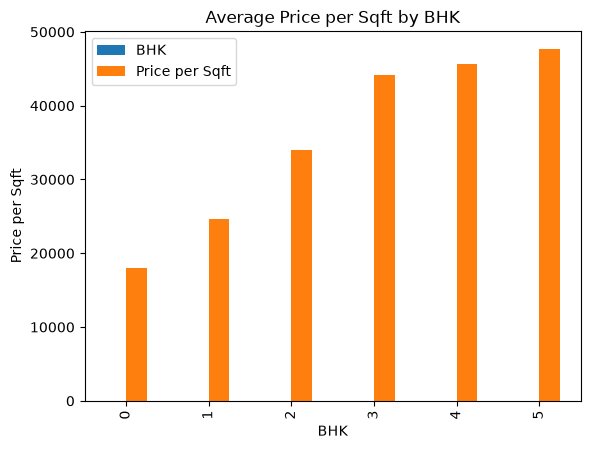

In [8]:
#Final Analysis
filtered_data.groupby('City').mean('Price per Sqft')
# filtered_data.City.unique()
avg_price_psf_bhk = (filtered_data.groupby('BHK')['Price per Sqft'].mean().sort_index().reset_index())

avg_price_psf_bhk.plot(kind='bar')

plt.title('Average Price per Sqft by BHK')
plt.xlabel('BHK')
plt.ylabel('Price per Sqft')
plt.show()


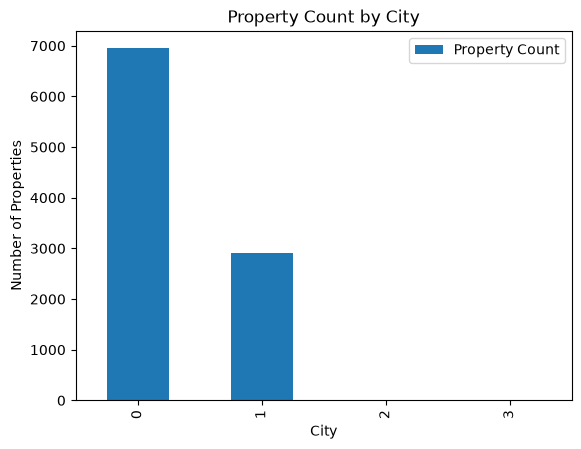

In [10]:
property_count_city = (filtered_data.groupby('City').size().sort_values(ascending=False).reset_index(name='Property Count'))
property_count_city
property_count_city.plot(kind='bar')

plt.title('Property Count by City')
plt.xlabel('City')
plt.ylabel('Number of Properties')
plt.show()